# <mark>위클리퀘스트 5번</mark>

In [1]:
import numpy as np

In [3]:
weighted_sum = np.arange(-10,10)

In [6]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0,x)

In [7]:
output_sigmoid = sigmoid(weighted_sum)
output_tanh = tanh(weighted_sum)
output_relu = relu(weighted_sum)

In [9]:
import matplotlib.pyplot as plt

/tmp/ipykernel_1686/3550196988.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


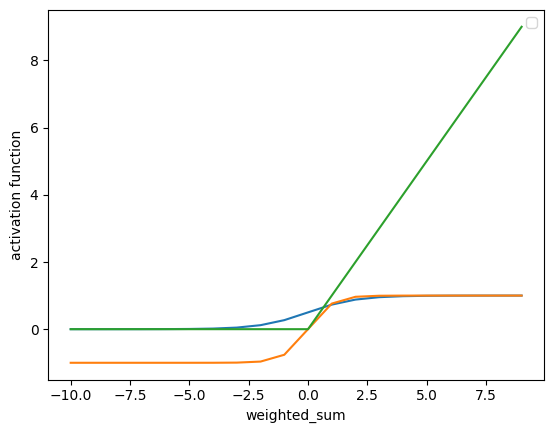

In [12]:
plt.plot(weighted_sum, output_sigmoid)
plt.plot(weighted_sum, output_tanh)
plt.plot(weighted_sum, output_relu)

plt.xlabel('weighted_sum')
plt.ylabel('activation function')
plt.show()

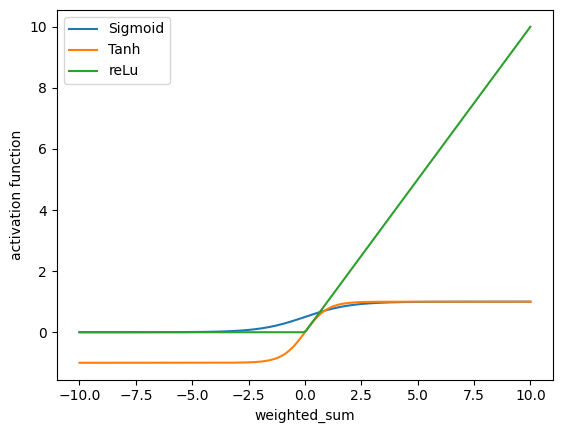

In [14]:
weighted_sum = np.linspace(-10,10, 200)

output_sigmoid = sigmoid(weighted_sum)
output_tanh = tanh(weighted_sum)
output_relu = relu(weighted_sum)

plt.plot(weighted_sum, output_sigmoid, label='Sigmoid')
plt.plot(weighted_sum, output_tanh, label='Tanh')
plt.plot(weighted_sum, output_relu, label='reLu')

plt.xlabel('weighted_sum')
plt.ylabel('activation function')
plt.legend()
plt.show()

## 🤖 claude와 함께
<br>
1. 입력을 받아 출력을 내놓는 함수면 형식상 다 활성화 함수가 될 수 있다. 다만, 실제로 쓸모가 있으려면

*   비선형이어야 한다.
*   미분 가능한 게 좋다.
<br>
2. 교재에 나오지 않은 다른 종류로는

*   Leaky ReLU
*   ELU, PReLU
*   GELU, Swish
*   Softmax
<br>

 ## <font color="red">claude 와 대화</font>
https://claude.ai/share/9386a95f-8c00-47ad-a51a-5ec9febed2f5




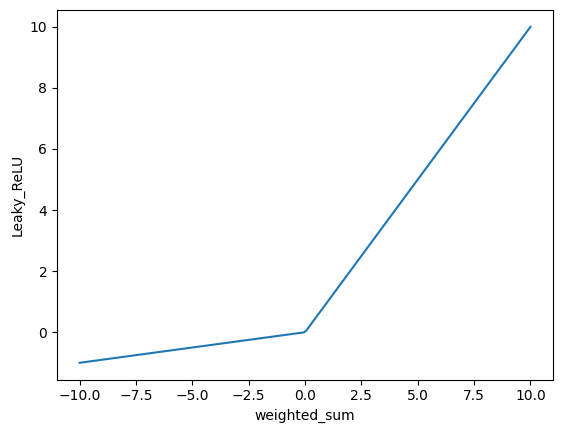

In [16]:
# 추가로 교재에 나와있지 않은 활성화 함수 작성해보기

def Leaky_relu(a, x):
  return np.where(x>=0, x, a*x)

output_leaky_relu = Leaky_relu(0.1,weighted_sum)

plt.plot(weighted_sum, output_leaky_relu)
plt.xlabel('weighted_sum')
plt.ylabel('Leaky_ReLU')
plt.show()

# <mark>위클리퀘스트 6번</mark>

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [19]:
X, y = make_moons(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [21]:
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='logistic', max_iter=1000) #logistic 이 sigmoid
mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', hidden_layer_sizes=10, max_iter=1000)

In [22]:
result = mlp.score(X_test, y_test)
print(result)

0.96


In [25]:
print("예측값 | 실제값")
print(np.column_stack((mlp.predict(X_test), y_test)))

예측값 | 실제값
[[0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]]


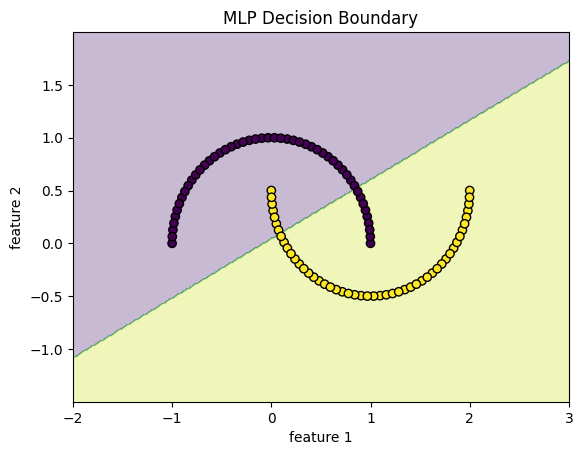

In [26]:
# 1. 그릴 범위 정하기 (양쪽에 여유 ±1)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 2. 격자 만들기 (300등분씩 촘촘하게)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# 3. 격자 점들을 좌표 목록으로 묶어서 예측
grid = np.c_[xx.ravel(), yy.ravel()]   # 각 줄이 [x, y] 한 점
Z = mlp.predict(grid)                  # 점마다 0/1 예측

# 4. 예측을 다시 격자 모양으로 되돌리기
Z = Z.reshape(xx.shape)

# 5. 배경 칠하기 (예측 영역별로 색)
plt.contourf(xx, yy, Z, alpha=0.3)

# 6. 실제 데이터 점 얹기 (실제 라벨 색으로)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('MLP Decision Boundary')
plt.show()

1.0


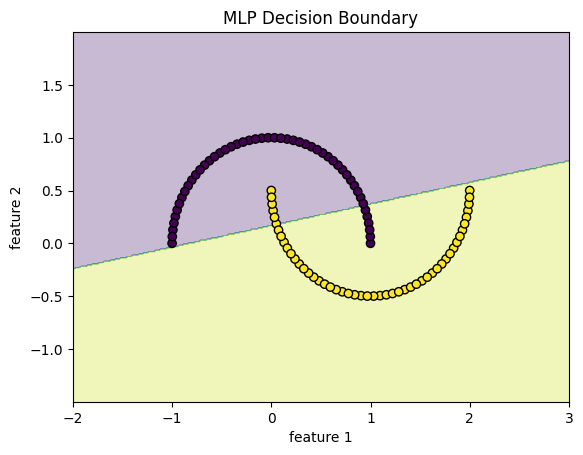

In [31]:
# ========= 🤖 제미나이와 함께 추가 =========
# 은닉층 100개로 증가, 활성화 함수 동일, 학습 최대 반복 횟수 2000으로 증가

mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='logistic', max_iter=2000)
mlp.fit(X_train, y_train)
result = mlp.score(X_test, y_test)
print(result)

# 그래프 출력
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('MLP Decision Boundary')
plt.show()

0.96


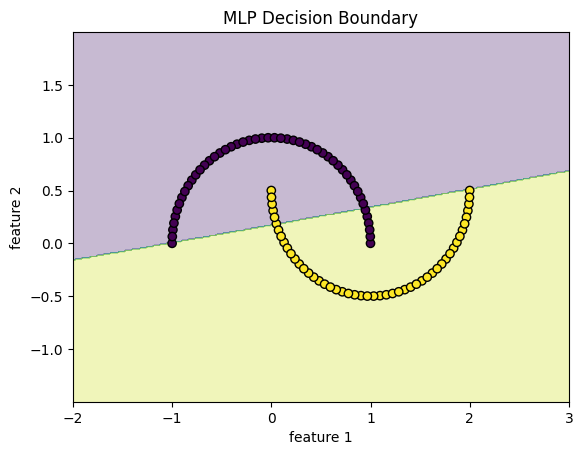

In [32]:
# ========= 🤖 제미나이와 함께 추가 =========
# 은닉층 30,30으로 (각 은닉층을 노드 30개씩, 2개의 층으로 제작), 활성화 함수 동일, 학습 최대 반복 횟수 2000으로 증가

mlp = MLPClassifier(hidden_layer_sizes=(30,30), activation='logistic', max_iter=2000)
mlp.fit(X_train, y_train)
result = mlp.score(X_test, y_test)
print(result)

# 그래프 출력
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.predict(grid)

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('MLP Decision Boundary')
plt.show()

## <font color="red"> claude 와 대화</font>
https://claude.ai/share/9386a95f-8c00-47ad-a51a-5ec9febed2f5

## <font color='red'>제미나이와 대화 : 추가학습 (은닉층 늘려보기, 학습수 늘려보기)</font>
https://gemini.google.com/share/1397e5e6785d

## <font color='red'>제미나이 : 은닉층에 대해 </font>
https://share.google/aimode/AptkdsGMztmvI2uov


# <mark>위클리퀘스트 7번</mark>

In [43]:
import keras

In [44]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [45]:
X_train = X_train/255
X_test = X_test/255

In [46]:
X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test,10)

In [47]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

model.evaluate(X_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 31ms/step - accuracy: 0.9553 - loss: 0.1483
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 28ms/step - accuracy: 0.9854 - loss: 0.0479
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9896 - loss: 0.0325
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.9923 - loss: 0.0244
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9937 - loss: 0.0193
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9956 - loss: 0.0134
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9958 - loss: 0.0127
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9972 - loss: 0.0089
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9975 - loss: 0.0076
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9975 - loss: 0.0075
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9892 - loss: 0.0417


NameError: name 'predictions' is not defined

In [52]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


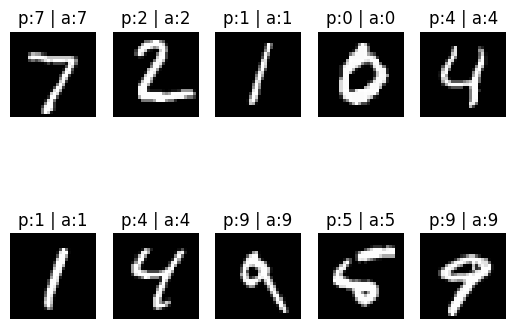

In [67]:
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_test[i].reshape(28,28), cmap='gray')
  plt.title(f"p:{predicted_labels[i]} | a:{actual_labels[i]}")
  plt.axis('off')

plt.show()

## <font color="red"> claude 와 대화</font>
https://claude.ai/share/9386a95f-8c00-47ad-a51a-5ec9febed2f5